# Short-Term Heat-Index Forecast — LSTM Development

This notebook develops the daily **heat-index** LSTM forecast used in the UPLB-NAS Weather
Dashboard and evaluates it rigorously against forecasting baselines. It mirrors the production
implementation in `src/models/forecast.py`.

**Sections**
1. Imports & setup
2. Load (direct from the database) & preprocess
3. The LSTM model
4. Train the model
5. Evaluation — model weights, baselines (incl. SARIMA), rolling-origin backtest, MASE, skill
   score, and a Diebold–Mariano significance test

> **Setup.** Install dependencies — `pip install -r requirements.txt -r requirements-notebook.txt` — and build the database once (`python -m src.data.ingest`). Then run all cells.
>
> Section 6 regenerates the artifact the live dashboard serves, so running it overwrites the tracked file `src/dashapp/forecast_precomputed.json`.

## 1. Imports & setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")   # quieten SARIMAX convergence chatter

# Make the project importable whether this runs from notebooks/ or the repo root.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("PyTorch", torch.__version__, "| device:", DEVICE)

PyTorch 2.12.1 | device: mps


## 2. Load & preprocess data

We read the **daily observations directly from the SQLite database** (`data/weather.db`) with a
SQL query, pivot to a wide table, and compute the daily heat index with the project's
`heat_index` module. The heat index uses daily maximum temperature + daily mean relative humidity
(which tends to *overestimate* — the forecast inherits this bias).

Preprocessing for the LSTM: **min–max scaling**, two **day-of-year features**
(`sin`/`cos` of the annual cycle, known for future dates), and **sliding windows**
(`LOOKBACK` days → next day).

In [2]:
import sqlite3
import config
from src.features import heat_index

# --- call the database directly ---
DB = str(config.DB_PATH)
if not Path(DB).exists():
    raise FileNotFoundError(f"Database not found at {DB}.\nBuild it first:  python -m src.data.ingest")

con = sqlite3.connect(DB)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", con)["name"].tolist()
if "observation_daily" not in tables:
    con.close()
    raise RuntimeError("Database has no observation table. Build it:  python -m src.data.ingest")

long = pd.read_sql_query(
    "SELECT o.date, v.name, o.value "
    "FROM observation_daily o JOIN variable v ON o.variable_id = v.variable_id "
    "WHERE o.station_id = 1 ORDER BY o.date",
    con, parse_dates=["date"],
)
con.close()

wide = long.pivot(index="date", columns="name", values="value").sort_index()
series = pd.Series(
    heat_index.heat_index_c(wide["max_temp"].to_numpy(), wide["relative_humidity"].to_numpy()),
    index=wide.index, name="hi_c",
).dropna()

print(f"queried {len(long):,} rows from {Path(config.DB_PATH).name}  ->  {len(series)} daily "
      f"heat-index values ({series.index.min().date()} -> {series.index.max().date()})")
series.describe().round(2)

queried 98,622 rows from weather.db  ->  10958 daily heat-index values (1996-01-01 -> 2025-12-31)


count    10958.00
mean        38.61
std          5.83
min         22.85
25%         34.47
50%         38.69
75%         42.84
max         60.76
Name: hi_c, dtype: float64

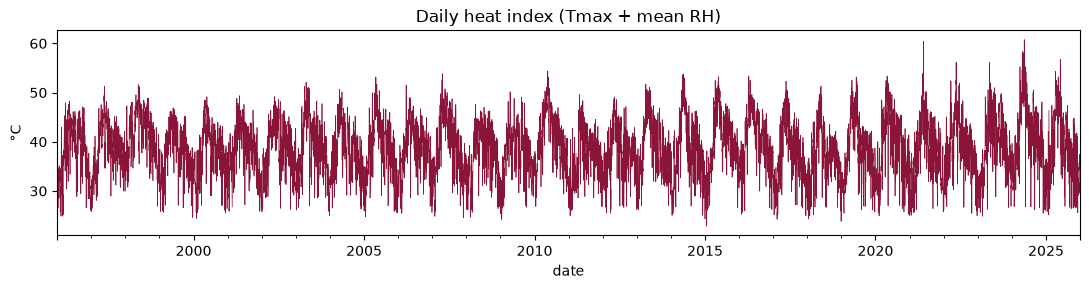

In [3]:
fig, ax = plt.subplots(figsize=(11, 3))
series.plot(ax=ax, lw=0.5, color="#8A1538")
ax.set_title("Daily heat index (Tmax + mean RH)"); ax.set_ylabel("°C")
plt.tight_layout(); plt.show()

In [4]:
LOOKBACK = 45               # input window length (days)
MAX_TRAIN_DAYS = 365 * 10   # train on the most recent ~10 years

def doy_features(index):
    """sin/cos of day-of-year -> (n, 2); known for future dates too."""
    doy = pd.DatetimeIndex(index).dayofyear.to_numpy()
    ang = 2 * np.pi * doy / 365.0
    return np.column_stack([np.sin(ang), np.cos(ang)])

def minmax_scale(values, vmin, vmax):
    return (values - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(values)

def make_windows(feats, target, lookback):
    X = np.array([feats[i - lookback:i] for i in range(lookback, len(feats))], dtype="float32")
    y = target[lookback:].astype("float32")
    return X, y

_s = series.iloc[-MAX_TRAIN_DAYS:]
_sc = minmax_scale(_s.to_numpy(dtype=float), float(_s.min()), float(_s.max()))
_feats = np.column_stack([_sc, doy_features(_s.index)]).astype("float32")
_X, _y = make_windows(_feats, _sc, LOOKBACK)
print("features/day:", _feats.shape[1], "| X:", _X.shape, "| y:", _y.shape)

features/day: 3 | X: (3605, 45, 3) | y: (3605,)


## 3. The LSTM model

A single-layer LSTM reads the window and predicts the next day's (scaled) heat index from its
last-timestep hidden state.

In [5]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features=3, units=48):
        super().__init__()
        self.lstm = nn.LSTM(n_features, units, batch_first=True)
        self.fc = nn.Linear(units, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

LSTMForecaster()

LSTMForecaster(
  (lstm): LSTM(3, 48, batch_first=True)
  (fc): Linear(in_features=48, out_features=1, bias=True)
)

## 4. Train the model

Adam (lr 0.01) on MSE, shuffled mini-batches of 32, up to 40 epochs with early stopping
(patience 3). We keep the residual standard deviation to scale forecast uncertainty. Forecasting
is **recursive multi-step**: predict day *t+1*, feed it back with the known future day-of-year
features, slide the window, repeat.

In [6]:
def train_lstm(train_series, lookback=LOOKBACK, units=48, epochs=40, lr=0.01,
               batch=32, seed=SEED, max_days=MAX_TRAIN_DAYS):
    torch.manual_seed(seed); np.random.seed(seed)
    s = train_series.dropna().iloc[-max_days:]
    vals = s.to_numpy(dtype=float)
    vmin, vmax = float(vals.min()), float(vals.max())
    scaled = minmax_scale(vals, vmin, vmax)
    feats = np.column_stack([scaled, doy_features(s.index)]).astype("float32")
    X, y = make_windows(feats, scaled, lookback)
    Xt = torch.from_numpy(X).to(DEVICE); yt = torch.from_numpy(y).to(DEVICE)

    model = LSTMForecaster(3, units).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()

    n = len(Xt); best = np.inf; patience = 0; history = []
    model.train()
    for _ in range(epochs):
        perm = torch.randperm(n, device=DEVICE); total = 0.0
        for i in range(0, n, batch):
            b = perm[i:i + batch]
            opt.zero_grad()
            loss = lossf(model(Xt[b]), yt[b])
            loss.backward(); opt.step()
            total += loss.item() * len(b)
        epoch_loss = total / max(n, 1); history.append(epoch_loss)
        if epoch_loss < best - 1e-4:
            best = epoch_loss; patience = 0
        else:
            patience += 1
            if patience >= 3:
                break

    model.eval()
    with torch.no_grad():
        resid = (yt.cpu().numpy() - model(Xt).cpu().numpy()) * (vmax - vmin)
    return dict(model=model, vmin=vmin, vmax=vmax, lookback=lookback,
                resid_std=float(resid.std()), history=history)


def lstm_forecast(fit, series_so_far, horizon):
    s = series_so_far.dropna()
    lookback, vmin, vmax, model = fit["lookback"], fit["vmin"], fit["vmax"], fit["model"]
    feats = np.column_stack([minmax_scale(s.to_numpy(dtype=float), vmin, vmax),
                             doy_features(s.index)]).astype("float32")
    window = feats[-lookback:].copy()
    fdates = pd.date_range(s.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    fdoy = doy_features(fdates).astype("float32")
    preds = []; model.eval()
    with torch.no_grad():
        for k in range(horizon):
            x = torch.from_numpy(window.reshape(1, lookback, 3)).to(DEVICE)
            p = float(model(x).item()); preds.append(p)
            window = np.vstack([window[1:], [p, fdoy[k, 0], fdoy[k, 1]]]).astype("float32")
    return fdates, np.array(preds) * (vmax - vmin) + vmin

stopped after 12 epochs | final train MSE 0.00909 | residual std 3.42 °C


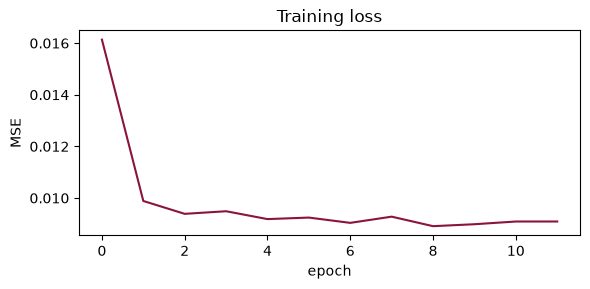

In [7]:
fit = train_lstm(series)
print(f"stopped after {len(fit['history'])} epochs | final train MSE {fit['history'][-1]:.5f} "
      f"| residual std {fit['resid_std']:.2f} °C")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(fit["history"], color="#8A1538")
ax.set_title("Training loss"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
plt.tight_layout(); plt.show()

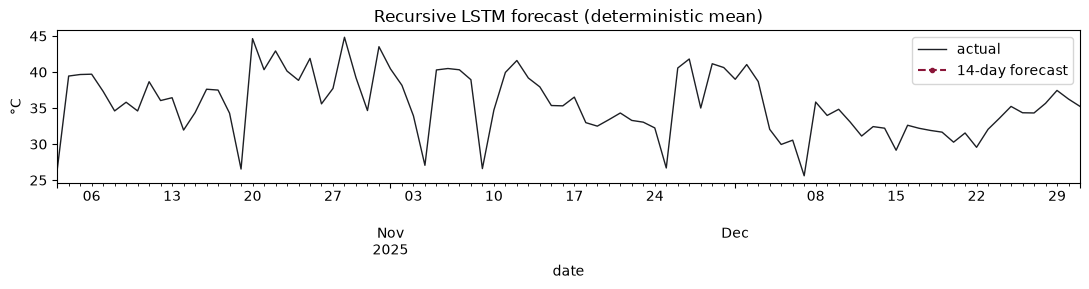

In [8]:
H = 14
fdates, yhat = lstm_forecast(fit, series, H)

fig, ax = plt.subplots(figsize=(11, 3))
series.tail(90).plot(ax=ax, color="#1D1F24", lw=1.0, label="actual")
ax.plot(fdates, yhat, color="#8A1538", ls="--", marker="o", ms=3, label=f"{H}-day forecast")
ax.set_title("Recursive LSTM forecast (deterministic mean)"); ax.set_ylabel("°C"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Evaluation

### 5.1 The trained model's weights

A single LSTM layer stores four gates — **input, forget, cell, output** — stacked together, so
each weight matrix has `4 × units` rows:

- `lstm.weight_ih_l0` — input → hidden, shape `(4·units, n_features)`
- `lstm.weight_hh_l0` — hidden → hidden (recurrent), shape `(4·units, units)`
- `lstm.bias_ih_l0`, `lstm.bias_hh_l0` — biases, shape `(4·units,)`
- `fc.weight`, `fc.bias` — the linear read-out from the hidden state to the 1-day prediction

In [9]:
model = fit["model"]
total = 0
for name, p in model.named_parameters():
    total += p.numel()
    print(f"{name:18s} {tuple(p.shape)!s:14s} {p.numel():>6,} params")
print(f"{'TOTAL':18s} {'':14s} {total:>6,} params")

lstm.weight_ih_l0  (192, 3)          576 params
lstm.weight_hh_l0  (192, 48)       9,216 params
lstm.bias_ih_l0    (192,)            192 params
lstm.bias_hh_l0    (192,)            192 params
fc.weight          (1, 48)            48 params
fc.bias            (1,)                1 params
TOTAL                             10,225 params


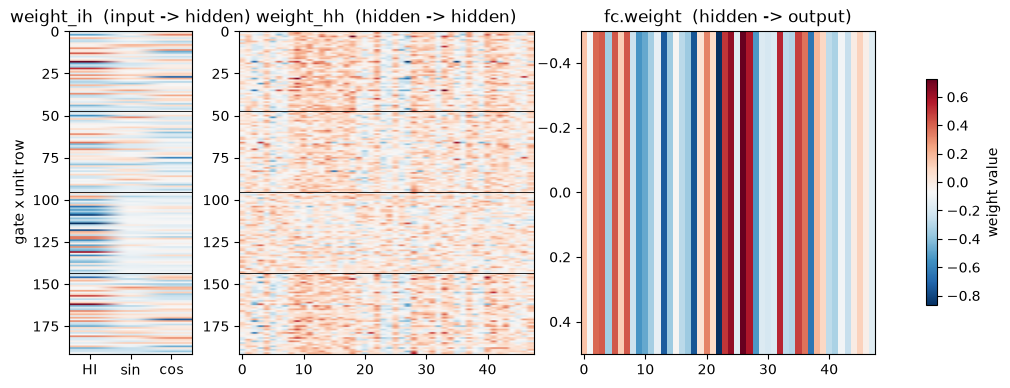

gate row blocks (top->bottom): input | forget | cell | output, each 48 rows


In [10]:
ih = model.lstm.weight_ih_l0.detach().cpu().numpy()
hh = model.lstm.weight_hh_l0.detach().cpu().numpy()
fcw = model.fc.weight.detach().cpu().numpy()
units = hh.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 2.4, 2.4]})
axes[0].imshow(ih, aspect="auto", cmap="RdBu_r")
axes[0].set_title("weight_ih  (input -> hidden)"); axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(["HI", "sin", "cos"]); axes[0].set_ylabel("gate x unit row")
im = axes[1].imshow(hh, aspect="auto", cmap="RdBu_r"); axes[1].set_title("weight_hh  (hidden -> hidden)")
axes[2].imshow(fcw, aspect="auto", cmap="RdBu_r"); axes[2].set_title("fc.weight  (hidden -> output)")
# gate boundaries (PyTorch order: input, forget, cell, output)
for ax in axes[:2]:
    for g in range(1, 4):
        ax.axhline(g * units - 0.5, color="k", lw=0.6)
fig.colorbar(im, ax=axes, shrink=0.7, label="weight value")
plt.show()

print("gate row blocks (top->bottom): input | forget | cell | output, each", units, "rows")

**Discussion.** PyTorch stacks the four gates row-wise (input, forget, cell, output); the
horizontal lines mark the block boundaries. The left panel shows how the three inputs
(scaled heat index, and the two seasonal terms) drive each gate; the middle panel is the recurrent
mixing of the hidden state; the right panel is the read-out vector that turns the final hidden
state into the prediction. Individual LSTM weights are **not directly interpretable** — the
seasonal and autoregressive signal is distributed across all units — but the magnitude patterns
show which units carry the most signal, and the residual spread (the `resid_std` printed above)
sets the width of the forecast's uncertainty band.

### 5.2 Baselines

- **Persistence** — repeat today's value.
- **Seasonal-naïve** — the value one year (365 days) ago.
- **Climatology** — the historical mean for that day-of-year (the benchmark to beat for a seasonal
  series).
- **SARIMA + Fourier** — an ARIMA model with annual **Fourier terms** as exogenous regressors
  (*dynamic harmonic regression*). This is the tractable way to give a statistical model the
  365-day seasonality that a classical seasonal ARIMA cannot handle directly.

In [11]:
def f_persistence(train, horizon, future_dates):
    return np.repeat(float(train.iloc[-1]), horizon)

def f_seasonal_naive(train, horizon, future_dates, m=365):
    arr = train.to_numpy(dtype=float); n = len(arr)
    return np.array([arr[n - 1 - m + h] if n - 1 - m + h >= 0 else arr[-1]
                     for h in range(1, horizon + 1)])

def f_climatology(train, horizon, future_dates):
    clim = train.groupby(train.index.dayofyear).mean()
    overall = float(train.mean())
    fdoy = pd.DatetimeIndex(future_dates).dayofyear
    return np.array([float(clim.get(int(d), overall)) for d in fdoy])

def _fourier(index, period=365.25, K=4):
    t = pd.DatetimeIndex(index).dayofyear.to_numpy(dtype=float)
    cols = []
    for k in range(1, K + 1):
        cols += [np.sin(2 * np.pi * k * t / period), np.cos(2 * np.pi * k * t / period)]
    return np.column_stack(cols)

def f_sarima(train, horizon, future_dates, K=4, order=(2, 0, 1), max_days=365 * 8):
    tr = train.iloc[-max_days:]
    exog = _fourier(tr.index, K=K); fexog = _fourier(future_dates, K=K)
    res = SARIMAX(tr.to_numpy(dtype=float), exog=exog, order=order, trend="c",
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return np.asarray(res.forecast(steps=horizon, exog=fexog))

### 5.3 Metrics and the Diebold–Mariano test

- **MAE / RMSE** (°C).
- **MASE** — MAE ÷ in-sample seasonal-naïve MAE; `< 1` beats the seasonal-naïve benchmark.
- **Skill vs climatology** — `1 − MSE_model / MSE_climatology`; `> 0` beats climatology.
- **Diebold–Mariano** — squared-error loss differential vs climatology across origins, with a
  Student-*t* reference distribution (scipy).

In [12]:
def insample_seasonal_mae(train, m=365):
    arr = train.to_numpy(dtype=float)
    return float(np.mean(np.abs(arr[m:] - arr[:-m])))

def diebold_mariano(err_a, err_b):
    """DM test (squared-error loss) on one error per origin at a fixed horizon."""
    d = err_a ** 2 - err_b ** 2
    n = len(d)
    if n < 3 or d.var(ddof=1) == 0:
        return float("nan"), float("nan")
    stat = d.mean() / np.sqrt(d.var(ddof=1) / n)
    p = float(2 * stats.t.sf(abs(stat), df=n - 1))
    return float(stat), p

### 5.4 Rolling-origin (walk-forward) backtest

The LSTM is re-trained and SARIMA re-fit at every origin, so this takes **a few minutes** (faster
on Apple-Silicon MPS). Reduce `N_ORIGINS` for a quicker run.

In [13]:
H = 14
N_ORIGINS = 24       # forecast origins
STEP = 30            # days between origins (~monthly)
MIN_TRAIN = 365 * 3  # require >= 3 years of history before an origin

s_full = series.dropna()
n = len(s_full)
last_origin = n - 1 - H
origins = sorted(o for o in (last_origin - STEP * i for i in range(N_ORIGINS)) if o - 1 >= MIN_TRAIN)
print(f"{len(origins)} origins: {s_full.index[origins[0]].date()} -> {s_full.index[origins[-1]].date()}")

BASELINES = {"Persistence": f_persistence, "Seasonal-naive": f_seasonal_naive,
             "Climatology": f_climatology, "SARIMA+Fourier": f_sarima}
errs = {m: [] for m in ["LSTM", *BASELINES]}
scale_denoms = []

for j, o in enumerate(origins):
    train = s_full.iloc[:o + 1]
    actual = s_full.iloc[o + 1:o + 1 + H].to_numpy(dtype=float)
    fdates = s_full.index[o + 1:o + 1 + H]
    scale_denoms.append(insample_seasonal_mae(train))

    fit_o = train_lstm(train)
    _, yhat_o = lstm_forecast(fit_o, train, H)
    errs["LSTM"].append(actual - yhat_o)
    for name, fn in BASELINES.items():
        errs[name].append(actual - fn(train, H, fdates))
    print(f"  origin {j + 1}/{len(origins)}  ({fdates[0].date()})   ", end="\r")

errs = {m: np.vstack(v) for m, v in errs.items()}   # shape (n_origins, H)
scale_mase = float(np.mean(scale_denoms))
print("\ndone. error array shape:", errs["LSTM"].shape)

24 origins: 2024-01-27 -> 2025-12-17
  origin 24/24  (2025-12-18)   
done. error array shape: (24, 14)


In [14]:
clim_sse = float(np.sum(errs["Climatology"] ** 2))
rows = []
for m, e in errs.items():
    rows.append({
        "model": m,
        "MAE": float(np.mean(np.abs(e))),
        "RMSE": float(np.sqrt(np.mean(e ** 2))),
        "MASE": float(np.mean(np.abs(e)) / scale_mase),
        "Skill vs clim": 1 - float(np.sum(e ** 2)) / clim_sse,
    })
results = pd.DataFrame(rows).set_index("model").sort_values("MAE").round(3)
results

,MAE,RMSE,MASE,Skill vs clim
model,,,,
SARIMA+Fourier,3.778,4.750,0.833,0.109
Climatology,4.068,5.033,0.897,0.000
LSTM,4.318,5.402,0.952,-0.152
Seasonal-naive,5.156,6.395,1.137,-0.615
Persistence,5.590,7.476,1.233,-1.207


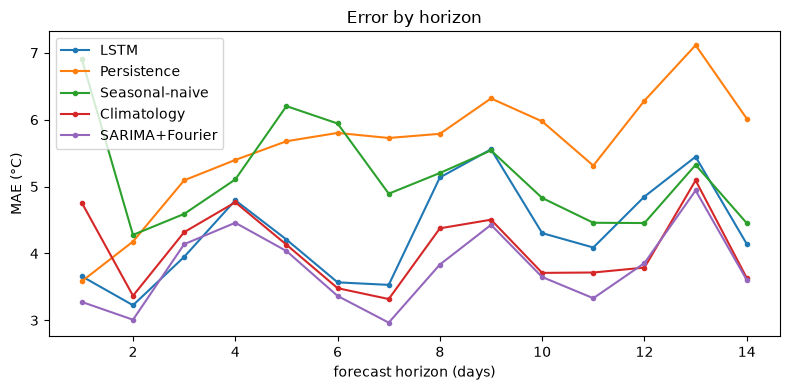

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
hor = np.arange(1, H + 1)
for m, e in errs.items():
    ax.plot(hor, np.mean(np.abs(e), axis=0), marker="o", ms=3, label=m)
ax.set_xlabel("forecast horizon (days)"); ax.set_ylabel("MAE (°C)")
ax.set_title("Error by horizon"); ax.legend()
plt.tight_layout(); plt.show()

In [16]:
print("Diebold-Mariano test - LSTM vs Climatology (squared error):")
for h in [7, 14]:
    a, b = errs["LSTM"][:, h - 1], errs["Climatology"][:, h - 1]
    stat, p = diebold_mariano(a, b)
    lower = "LSTM" if np.mean(a ** 2) < np.mean(b ** 2) else "Climatology"
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  h={h:2d} days:  DM={stat:+.2f}  p={p:.3f}  ({sig}; lower error: {lower})")

Diebold-Mariano test - LSTM vs Climatology (squared error):
  h= 7 days:  DM=+1.12  p=0.275  (not significant; lower error: Climatology)
  h=14 days:  DM=+1.57  p=0.130  (not significant; lower error: Climatology)


### How to read the results

- **MASE < 1** → beats the seasonal-naïve benchmark; **> 1** → it does not.
- **Skill vs clim > 0** → beats climatology (climatology's own skill is 0 by definition).
- **DM p < 0.05** → the error difference vs climatology is statistically significant.

For a strongly seasonal daily series, climatology and SARIMA+Fourier are *hard* baselines at longer
horizons. Report the outcome honestly: if the LSTM only matches them at 14 days, that is itself a
finding and reframes the contribution toward the application (operational heat-index forecasting)
rather than the method.

**Caveats.** This uses the Open-Meteo (ERA5) **stand-in**; the heat index is computed from Tmax +
daily-mean RH (overestimation); and rolling origins overlap slightly (a mild violation of the DM
independence assumption). Re-fit and re-evaluate once the real UPLB-NAS records are integrated.

## 6. Update the deployed model

The website does **not** train at runtime — it serves a precomputed artifact,
`src/dashapp/forecast_precomputed.json`, written by `src/models/precompute.py`, which uses the
production model in `src/models/forecast.py` (the same LSTM developed and evaluated above).

Running the cell below **retrains on the current database and overwrites that artifact**, so the
live dashboard immediately serves the updated model.

**Workflow after refreshing the data**
1. ingest the station data into `data/weather.db` (`python -m src.data.ingest`),
2. run the cell below — or, equivalently, `python -m src.models.precompute`,
3. restart / redeploy the app.

Because both this notebook and `precompute` read the database directly, no code changes are needed
when the underlying data changes — only re-ingest and re-run. (The production model lives in
`src/models/forecast.py`; if you change the architecture/hyperparameters here, mirror them there so
the deployed model matches.)

In [17]:
from src.dashapp import data as _appdata
from src.models import precompute

_appdata.clear()      # drop cached DB reads so we use the *current* database
precompute.main()     # retrains via src/models/forecast.py and overwrites the artifact
print("\nUpdated src/dashapp/forecast_precomputed.json - the dashboard now serves this model.")

  horizon  7: MAE 2.44  RMSE 2.68
  horizon 14: MAE 2.39  RMSE 2.78
wrote /Users/dgonzales22/Documents/AVCAD Project/avcad-project-uplb-weather-dashboard/src/dashapp/forecast_precomputed.json

Updated src/dashapp/forecast_precomputed.json - the dashboard now serves this model.
